Data exploration of the RSNA Bone Age Classification project.

In [1]:
import pandas as pd 
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import glob
import statistics
import random
import math


In [2]:
# Load the data 
base_dir: str = '/Users/julielasry/VScode_projects/Intermediate_projects/Bone_Age_Classification_Regression/data/raw/'

raw_data: pd.DataFrame = pd.read_csv(os.path.join(base_dir, 'boneage-training-dataset.csv'), header=0)
raw_images: os = os.path.join(base_dir, 'boneage-training-dataset/boneage-training-dataset')

print(f"CSV header :\n{raw_data.head()}\n")
data: pd.DataFrame = raw_data.dropna()
for i, column in enumerate(data.columns):
    print(f"Column {i}: {column}")
print(f"\nThere are : {data.shape[0]} rows and {data.shape[1]} columns.")
print(f"\nCSV count of NA values :\n{data.isna().sum()}")
print(f"\nCSV count of null values :\n{data.isnull().sum()}")


CSV header :
      id  boneage   male
0   9420       18  False
1  15140       60  False
2  13330       60  False
3   5108       60  False
4  15164       60  False

Column 0: id
Column 1: boneage
Column 2: male

There are : 2000 rows and 3 columns.

CSV count of NA values :
id         0
boneage    0
male       0
dtype: int64

CSV count of null values :
id         0
boneage    0
male       0
dtype: int64


In [3]:
# Check if all the images have an ID to classify the bone age
available: set = set(os.listdir(raw_images))
data['filename'] = data['id'].astype(str) + '.png'
csv: pd.DataFrame = data[data['filename'].isin(available)].reset_index(drop=True)

print(f"\nNumber of patients        : {len(csv)}")
print(f"Number of male patients   : {len(csv[csv['male'] == True])}")
print(f"Number of female patients : {len(csv[csv['male'] == False])}")



Number of patients        : 2000
Number of male patients   : 1084
Number of female patients : 916


In [4]:
# Check the max and min of the bone age 
print(f"\nMin of the bone age    : {min(csv['boneage'])}")
print(f"Max of the bone age    : {max(csv['boneage'])}")
print(f"Mean of the bone age   : {np.mean(csv['boneage']):0.1f}")
print(f"Median of the bone age : {np.median(csv['boneage'])}\n")



Min of the bone age    : 9
Max of the bone age    : 228
Mean of the bone age   : 127.7
Median of the bone age : 132.0



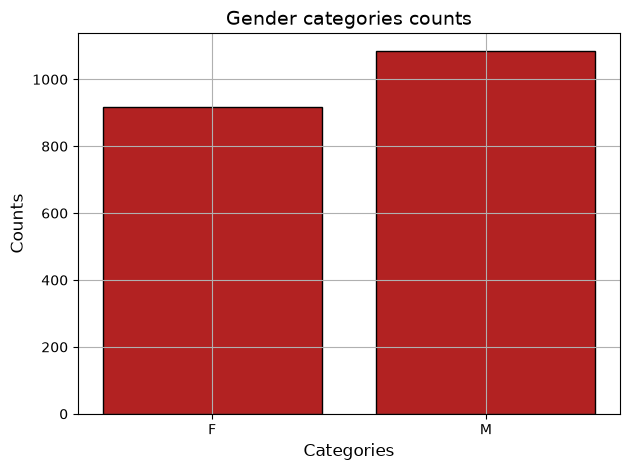

In [5]:
# Printing the bar charts
# - For the Male and Female categories 
male_counts = csv['male'].value_counts()
male_charts = plt.bar(male_counts.index, male_counts.values, color='firebrick', edgecolor='black')
plt.title('Gender categories counts', fontsize=14)
plt.xlabel('Categories', fontsize=12)
plt.xticks([0, 1], ['F', 'M'])
plt.ylabel('Counts', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


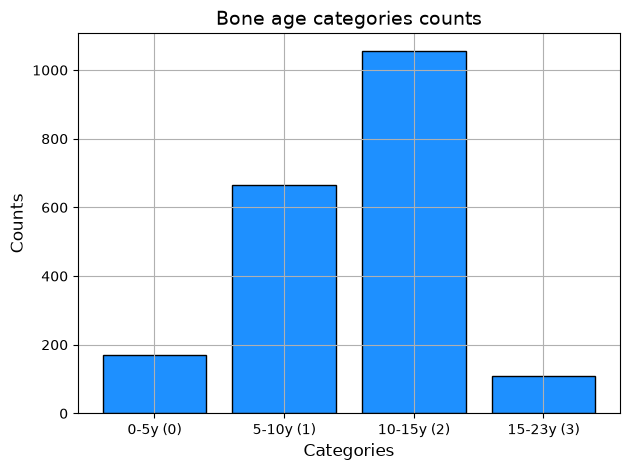

In [6]:
# - For the Bone age categories 
# 0 = 0-5 years old 
# 1 = 5-10 years old 
# 2 = 10-15 years old 
# 3 = 15-23 years old 
labels: list[int] = [0, 1, 2, 3]
thresholds: list[int] = [0, 60, 120, 180, np.inf]
csv['label'] = pd.cut(csv['boneage'], thresholds, labels=labels)
    
boneage_counts = csv['label'].value_counts()
boneage_charts = plt.bar(boneage_counts.index, boneage_counts.values, color='dodgerblue', edgecolor='black')
plt.title('Bone age categories counts', fontsize=14)
plt.xlabel('Categories', fontsize=12)
plt.xticks(labels, ['0-5y (0)', '5-10y (1)', '10-15y (2)', '15-23y (3)'])
plt.ylabel('Counts', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


All the files were analyzed.
If there wasn't a non-PNG warning messsage, then all files are PNG.



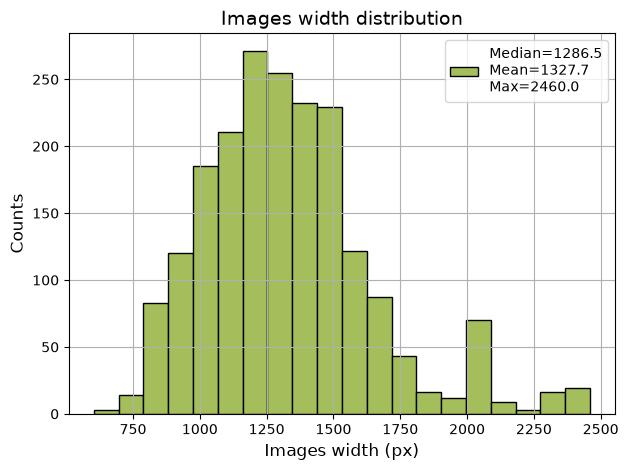

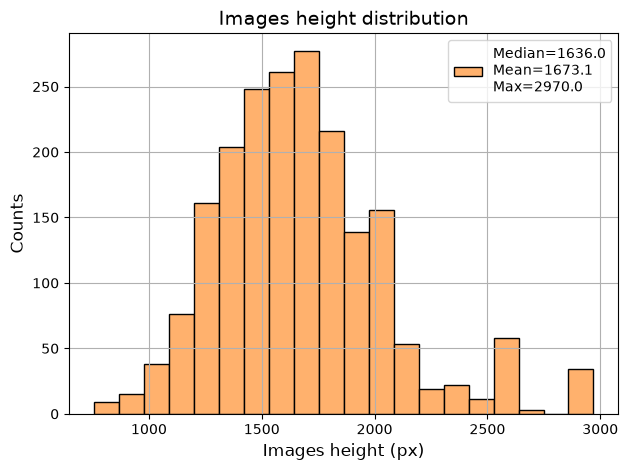

In [7]:
# Images type and histograms of dimensions 
img_widths: list[int] = []
img_heights: list[int] = []

for img in glob.glob(f'{base_dir}/boneage-training-dataset/boneage-training-dataset/*'):
    if not img.endswith('.png'):
        print(f"There are non-PNG files : {img}")

    with Image.open(img) as pil_img:
        img_w, img_h = pil_img.size
        img_widths.append(img_w)
        img_heights.append(img_h)
    
print("All the files were analyzed.\nIf there wasn't a non-PNG warning messsage, then all files are PNG.\n")

median_w: float = statistics.median(img_widths)
mean_w: float = statistics.mean(img_widths)
max_w: float = np.max(img_widths)

median_h: float = statistics.median(img_heights)
mean_h: float = statistics.mean(img_heights)
max_h: float = np.max(img_heights)

plt.hist(img_widths, bins=20, color='xkcd:light olive green', edgecolor='black', label=f'Median={median_w:.1f}\nMean={mean_w:.1f}\nMax={max_w:.1f}')
plt.title("Images width distribution", fontsize=14)
plt.xlabel("Images width (px)", fontsize=12)
plt.ylabel("Counts", fontsize=12)
plt.tight_layout()
plt.legend()
plt.grid(True)
plt.show()

plt.hist(img_heights, bins=20, color='xkcd:apricot', edgecolor='black', label=f'Median={median_h:.1f}\nMean={mean_h:.1f}\nMax={max_h:.1f}')
plt.title("Images height distribution", fontsize=14)
plt.xlabel("Images height (px)", fontsize=12)
plt.ylabel("Counts", fontsize=12)
plt.tight_layout()
plt.legend()
plt.grid(True)
plt.show()


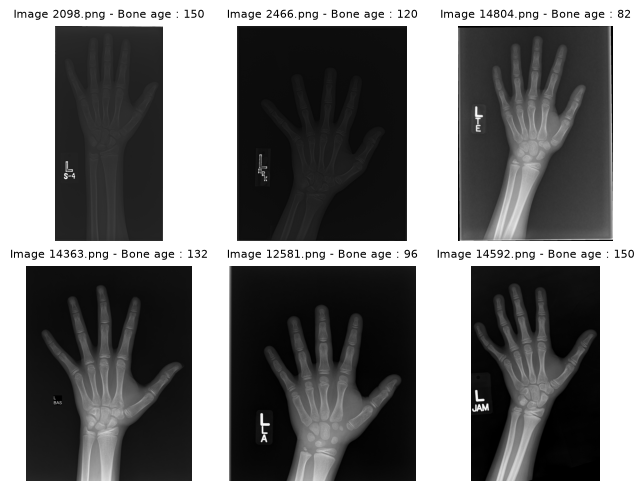

In [8]:
# Display some random images and their bone age 
num_display_samples: int = 6
num_columns: int = 3

display_figure: plt.Figure = plt.figure(layout="constrained")
display_axes: np.ndarray = display_figure.subplots(
    nrows=math.ceil(num_display_samples / num_columns),
    ncols=num_columns
)
for i in range(num_display_samples):
    display_sample_idx: int = random.randint(0, len(available))

    filename: str = data['filename'][display_sample_idx]
    boneage: int = data['boneage'][display_sample_idx]
    img = f'{base_dir}/boneage-training-dataset/boneage-training-dataset/{filename}'

    with Image.open(img) as pil_img:
        ax: plt.Axes = display_axes[
            i // num_columns, 
            i % num_columns
        ]
        ax.imshow(pil_img, cmap='gray')
        ax.set_title(f"Image {filename} - Bone age : {boneage}", fontsize=8)
        ax.axis("off")
plt.show()
